In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
np.random.seed(42)


In [2]:
class CollegeMatchingProblem:
    #Represents a many-to-one matching problem with stochastic rewards.
    def __init__(self, n_students, n_colleges, capacities, seed=42):
        self.n_students = n_students
        self.n_colleges = n_colleges
        self.capacities = capacities
        np.random.seed(seed)
        self.true_means = np.random.rand(n_students, n_colleges)
    def sample_reward(self, student, college):
        #Sample a Bernoulli reward for student-college pair.
        return np.random.binomial(1, self.true_means[student, college])


In [3]:
class GraphTransformer:
    #Converts capacity constraints to virtual slots for bipartite matching. K-K matching
    def __init__(self, problem):
        self.problem = problem
        self.virtual_colleges = []
        self.virtual_to_college = {}
        slot_id = 0
        for college_id in range(problem.n_colleges):
            for _ in range(problem.capacities[college_id]):
                self.virtual_colleges.append(slot_id)
                self.virtual_to_college[slot_id] = college_id
                slot_id += 1
        self.n_virtual = len(self.virtual_colleges)


In [4]:
def solve_matching_hungarian(cost_matrix):
    # 1-1 matching using Hungarian algorithm.   (cost_matrix: Negated utility matrix (for maximization)).
    student_indices, slot_indices = linear_sum_assignment(cost_matrix)
    return list(zip(student_indices, slot_indices))


In [5]:
class CombUCB1:

    def __init__(self, problem, transformer, horizon, debug=False):
        self.problem = problem
        self.transformer = transformer
        self.horizon = horizon
        self.debug = debug
        self.n_students = problem.n_students
        self.n_colleges = problem.n_colleges
        self.n_virtual = transformer.n_virtual
        # Track pulls and rewards on real edges only
        self.counts = np.zeros((self.n_students, self.n_colleges))
        self.rewards_sum = np.zeros((self.n_students, self.n_colleges))
        self.regrets = []
        self.optimal_value = self._compute_optimal_value()
    def _compute_optimal_value(self):
        #Compute the expected value of the optimal matching under true means.
        virtual_matrix = self._expand_to_virtual_matrix(self.problem.true_means)
        student_indices, slot_indices = linear_sum_assignment(-virtual_matrix)
        return sum(
            virtual_matrix[s, v] for s, v in zip(student_indices, slot_indices)
        )
    def _expand_to_virtual_matrix(self, real_matrix):
        #Expand real edge estimates to virtual slots.
        virtual_matrix = np.zeros((self.n_students, self.n_virtual))
        for student in range(self.n_students):
            for slot in range(self.n_virtual):
                college = self.transformer.virtual_to_college[slot]
                virtual_matrix[student, slot] = real_matrix[student, college]
        return virtual_matrix
    def _virtual_to_real_matching(self, virtual_matching):
        #Convert Hungarian output from virtual slots to real colleges.
        return [
            (student, self.transformer.virtual_to_college[slot])
            for student, slot in virtual_matching
        ]
    def _validate_matching(self, virtual_matching):
        #Verify matching respects constraints.

        students = [s for s, _ in virtual_matching]
        slots = [v for _, v in virtual_matching]
        colleges = [
            self.transformer.virtual_to_college[v] for _, v in virtual_matching
        ]
        assert len(students) == len(set(students)), (
            "Student matched multiple times"
        )
        assert len(slots) == len(set(slots)), (
            "Virtual slot used multiple times"
        )
        for college_id in range(self.n_colleges):
            usage = colleges.count(college_id)
            capacity = self.problem.capacities[college_id]
            assert usage <= capacity, (
                f"College {college_id}: used {usage}, capacity {capacity}"
            )
    def _print_debug_info(self, virtual_ucb):
        #Debug output showing shared estimates across virtual slots.
        print("\nShared estimates:")
        for student in range(self.n_students):
            for college in range(self.n_colleges):
                slots_for_college = [
                    v for v in range(self.n_virtual)
                    if self.transformer.virtual_to_college[v] == college
                ]
                ucb_values = [virtual_ucb[student, v] for v in slots_for_college]
                print(
                    f"Student {student}, College {college}: "
                    f"slots={slots_for_college}, "
                    f"UCB={np.round(ucb_values, 4).tolist()}, "
                    f"pulls={int(self.counts[student, college])}, "
                    f"mean={self.rewards_sum[student, college] / max(self.counts[student, college], 1):.4f}"
                )
    def run(self):
        #Run the CombUCB1 algorithm for the specified horizon.
        # Initialize: pull each real edge once
        for student in range(self.n_students):
            for college in range(self.n_colleges):
                reward = self.problem.sample_reward(student, college)
                self.counts[student, college] = 1
                self.rewards_sum[student, college] = reward
        # Main loop
        for t in range(1, self.horizon + 1):
            # Compute UCB indices on real edges
            mean = self.rewards_sum / self.counts
            bonus = np.sqrt((1.5 * np.log(t + 1)) / self.counts)
            real_ucb = mean + bonus
            # Expand to virtual slots for the matching
            virtual_ucb = self._expand_to_virtual_matrix(real_ucb)
            # Solve the matching
            student_indices, slot_indices = linear_sum_assignment(-virtual_ucb)
            virtual_matching = list(zip(student_indices, slot_indices))
            self._validate_matching(virtual_matching)
            if self.debug and t == 1:
                print(f"Virtual matching (t={t}): {virtual_matching}")
                print(f"Real matching (t={t}): {self._virtual_to_real_matching(virtual_matching)}")
                self._print_debug_info(virtual_ucb)
            # Run the matching and update estimates
            step_reward = 0.0
            for student, slot in virtual_matching:
                college = self.transformer.virtual_to_college[slot]
                step_reward += self.problem.true_means[student, college]
                reward = self.problem.sample_reward(student, college)
                self.counts[student, college] += 1
                self.rewards_sum[student, college] += reward
            regret = self.optimal_value - step_reward
            self.regrets.append(regret)
        return self.regrets

## Basic Test Run
Small instance to verify the algorithm works and see shared estimates in action.


In [6]:
n_students = 5
n_colleges = 3
capacities = [2, 2, 1]
horizon = 500
problem = CollegeMatchingProblem(n_students, n_colleges, capacities)
transformer = GraphTransformer(problem)
algo = CombUCB1(problem, transformer, horizon, debug=True)
regrets = algo.run()
cumulative_regret = np.cumsum(regrets)


Virtual matching (t=1): [(np.int64(0), np.int64(2)), (np.int64(1), np.int64(0)), (np.int64(2), np.int64(3)), (np.int64(3), np.int64(4)), (np.int64(4), np.int64(1))]
Real matching (t=1): [(np.int64(0), 1), (np.int64(1), 0), (np.int64(2), 1), (np.int64(3), 2), (np.int64(4), 0)]

Shared estimates:
Student 0, College 0: slots=[0, 1], UCB=[1.0197, 1.0197], pulls=1, mean=0.0000
Student 0, College 1: slots=[2, 3], UCB=[2.0197, 2.0197], pulls=1, mean=1.0000
Student 0, College 2: slots=[4], UCB=[2.0197], pulls=1, mean=1.0000
Student 1, College 0: slots=[0, 1], UCB=[2.0197, 2.0197], pulls=1, mean=1.0000
Student 1, College 1: slots=[2, 3], UCB=[1.0197, 1.0197], pulls=1, mean=0.0000
Student 1, College 2: slots=[4], UCB=[1.0197], pulls=1, mean=0.0000
Student 2, College 0: slots=[0, 1], UCB=[1.0197, 1.0197], pulls=1, mean=0.0000
Student 2, College 1: slots=[2, 3], UCB=[2.0197, 2.0197], pulls=1, mean=1.0000
Student 2, College 2: slots=[4], UCB=[2.0197], pulls=1, mean=1.0000
Student 3, College 0: slot

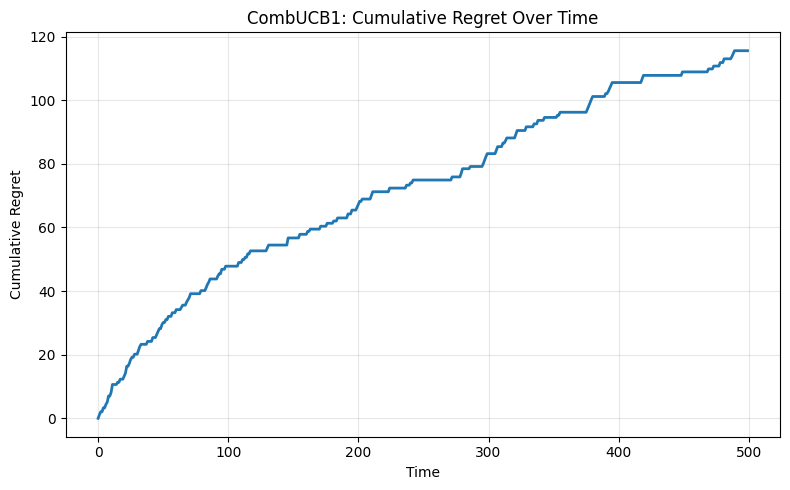

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(cumulative_regret, linewidth=2)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.title("CombUCB1: Cumulative Regret Over Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Gap Sensitivity
Check regret across different gaps. Larger gaps should be easier to learn.


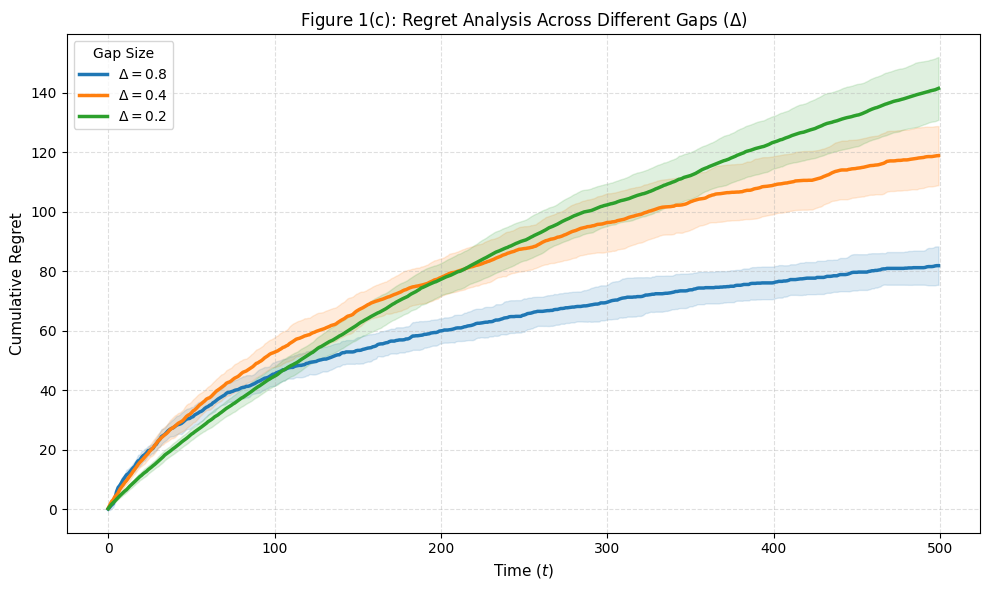

In [8]:
def evaluate_gap_sensitivity(horizon=500, num_runs=20):
    #Evaluate cumulative regret for different reward gaps.
    gaps = [0.8, 0.4, 0.2]
    colors = ['tab:blue', 'tab:orange', 'tab:green']

    plt.figure(figsize=(10, 6))
    for gap, color in zip(gaps, colors):
        all_regrets = []
        for run in range(num_runs):
            # Create environment with optimal configuration
            env = CollegeMatchingProblem(5, 3, [2, 2, 1], seed=run)
            env.true_means.fill(0.9 - gap)
            # Set optimal matching rewards to 0.9
            env.true_means[0, 0] = 0.9
            env.true_means[1, 0] = 0.9
            env.true_means[2, 1] = 0.9
            env.true_means[3, 1] = 0.9
            env.true_means[4, 2] = 0.9
            transformer = GraphTransformer(env)
            algo = CombUCB1(env, transformer, horizon)
            regrets = algo.run()
            all_regrets.append(np.cumsum(regrets))
        # Plot mean and confidence band
        regrets_array = np.array(all_regrets)
        mean_regret = np.mean(regrets_array, axis=0)
        std_regret = np.std(regrets_array, axis=0)
        plt.plot(mean_regret, label=rf"$\Delta = {gap}$", color=color, linewidth=2.5)
        plt.fill_between(
            range(horizon),
            mean_regret - std_regret,
            mean_regret + std_regret,
            color=color,
            alpha=0.15
        )
    plt.xlabel(r"Time ($t$)", fontsize=11)
    plt.ylabel("Cumulative Regret", fontsize=11)
    plt.title(r"Figure 1(c): Regret Analysis Across Different Gaps ($\Delta$)", fontsize=12)
    plt.legend(title="Gap Size", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
evaluate_gap_sensitivity()
